In [14]:
import numpy as np
import matplotlib.pyplot as plt
import random as rnd
import time as t
import os 
import sys
import pandas as pd
print(f"imported at: {t.ctime()}")

import rdkit
from rdkit import Chem
from rdkit.Chem.Descriptors import ExactMolWt
from rdkit.Chem.Crippen import MolLogP
from rdkit.Chem.rdMolDescriptors import CalcTPSA

# rdkitdraw
from rdkit.Chem import Draw
import py3Dmol as dmol
from rdkit.Chem import AllChem

imported at: Sun Feb 15 23:23:22 2026


    train_loss  test_loss
0     1.012964   0.665527
1     0.549688   0.513081
2     0.424258   0.438143
3     0.356081   0.384559
4     0.305820   0.350354
..         ...        ...
95    0.092209   0.263540
96    0.091987   0.260620
97    0.091749   0.263670
98    0.091527   0.264104
99    0.091421   0.266482

[100 rows x 2 columns]


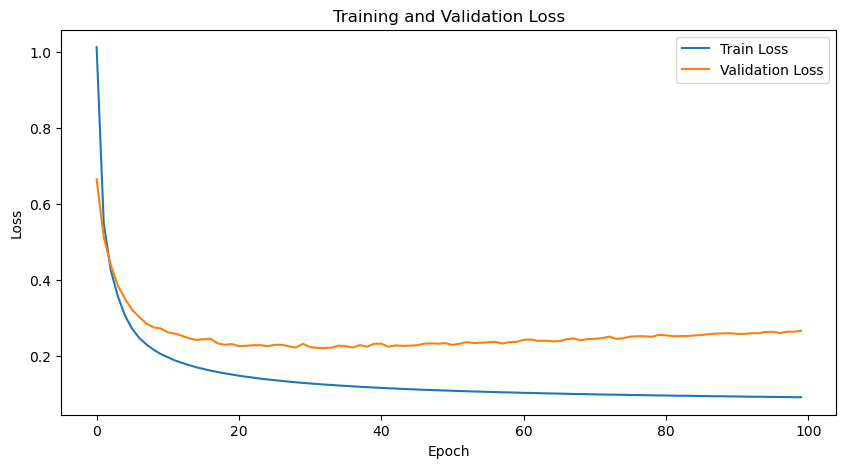

In [ ]:
save_folder = "save/"
file = "history.csv"

df = pd.read_csv(save_folder + file)
print(df)

def plot_history(df:pd.DataFrame, save_folder:str, file:str):
    x = np.linspace(0, len(df)-1, len(df))
    plt.figure(figsize=(10, 5))
    plt.plot(x, df['train_loss'], label='Train Loss')
    plt.plot(x, df['test_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')


    plt.savefig(save_folder + "history_plot.png")
    plt.show()


plot_history(df, save_folder, file)

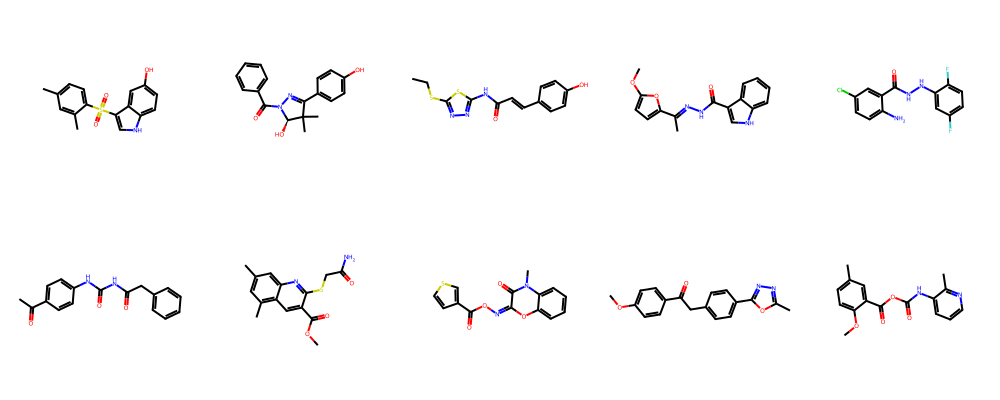

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

...

None

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None

In [ ]:
# read molecules from file
# has columns: smiles, MW, LogP, TPSA
df = pd.read_csv("result.txt")



ms = [Chem.MolFromSmiles(s) for s in df['smiles']]
def avg_mv(mols):
    return sum([ExactMolWt(m) for m in mols])/len(mols)


samples = 10


def draw_samples(mols: list, samples: int) -> None:
    sample_mols = rnd.sample(mols, samples)
    img = Draw.MolsToGridImage(sample_mols, molsPerRow=5, subImgSize=(200, 200))
    display(img)



def draw_3d_samples(mols: list, samples: int) -> None:
    sample_mols = rnd.sample(mols, samples)
    for mol in sample_mols:
        # add hydrogens and embed the molecule in 3D space
        mol = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol)
        # optimize the molecule
        # for better visualization
        AllChem.MMFFOptimizeMolecule(mol)
        view = dmol.view(width=400, height=400)
        view.addModel(Chem.MolToMolBlock(mol), 'sdf')
        view.setStyle({'stick': {}})
        view.zoomTo()
        display(view.show())
    



draw_samples(ms, samples)

draw_3d_samples(ms, samples)

